# Task 4: Insights, Visualisations & Recommendations
## Customer Experience Analytics — Ethiopian Bank Mobile Apps

**Objective:** Synthesise the sentiment and thematic analysis into business-actionable
insights supported by clear visualisations, and translate findings into concrete product
recommendations for each bank.

**Structure:**
1. Data loading & overview
2. Visualisation 1 — Sentiment distribution by bank (stacked bar)
3. Visualisation 2 — Rating distribution per bank (histogram)
4. Visualisation 3 — Top keywords per bank (horizontal bar chart)
5. Visualisation 4 — Theme frequency per bank (grouped bar)
6. Visualisation 5 — Sentiment trend over time
7. Per-bank satisfaction drivers & pain points
8. Bank-specific product recommendations
9. Ethical considerations & limitations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings, os
warnings.filterwarnings('ignore')

os.chdir('/home/code0053/fintech-review-analytics')
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

BANK_COLORS = {
    'Commercial Bank of Ethiopia': '#3b82f6',
    'Bank of Abyssinia':           '#f59e0b',
    'Dashen Bank':                 '#10b981',
}
BANK_SHORT = {
    'Commercial Bank of Ethiopia': 'CBE',
    'Bank of Abyssinia':           'BOA',
    'Dashen Bank':                 'Dashen',
}
SENTIMENT_COLORS = {'positive': '#16a34a', 'neutral': '#64748b', 'negative': '#dc2626'}
print("Imports ready.")

Imports ready.


In [2]:
df = pd.read_csv('data/raw/bank_reviews_sentiment.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M')

print(f"Dataset: {df.shape[0]} reviews, {df['bank'].nunique()} banks")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print()
print(df.groupby('bank')[['rating','sentiment_score']].mean().round(2))

Dataset: 1837 reviews, 3 banks
Date range: 2022-07-16 → 2026-05-14

                             rating  sentiment_score
bank                                                
Bank of Abyssinia              3.29             0.12
Commercial Bank of Ethiopia    3.93             0.24
Dashen Bank                    3.86             0.27


## Visualisation 1 — Sentiment Distribution by Bank

**Business question:** Which bank has the highest share of positive reviews? Which has the most negative?

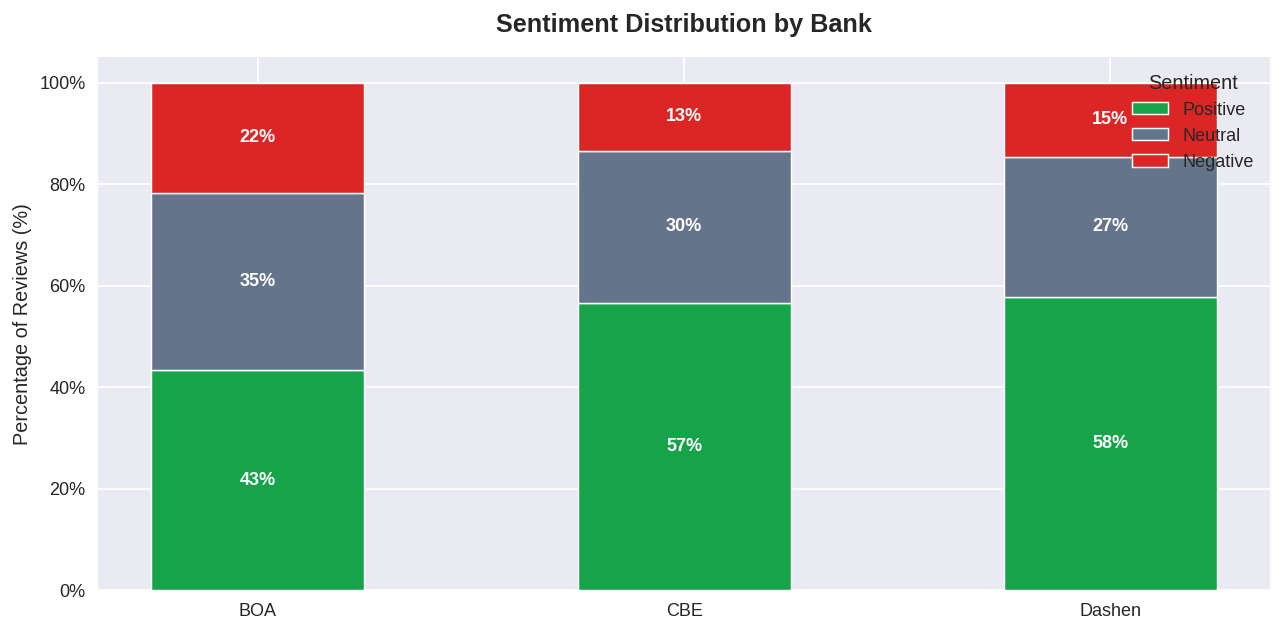

Saved → notebooks/viz1_sentiment_distribution.png
sentiment_label              positive  neutral  negative
bank                                                    
Bank of Abyssinia                43.4     34.9      21.7
Commercial Bank of Ethiopia      56.6     30.0      13.4
Dashen Bank                      57.9     27.5      14.7


In [3]:
sentiment_counts = df.groupby(['bank','sentiment_label']).size().unstack(fill_value=0)
for col in ['positive','neutral','negative']:
    if col not in sentiment_counts.columns:
        sentiment_counts[col] = 0
sentiment_counts = sentiment_counts[['positive','neutral','negative']]
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(sentiment_pct))
for label, color in SENTIMENT_COLORS.items():
    values = sentiment_pct[label].values
    bars = ax.bar(
        [BANK_SHORT[b] for b in sentiment_pct.index],
        values, bottom=bottom, color=color, label=label.capitalize(),
        edgecolor='white', linewidth=0.8, width=0.5
    )
    for bar, val, bot in zip(bars, values, bottom):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2, f'{val:.0f}%',
                    ha='center', va='center', color='white',
                    fontsize=10, fontweight='bold')
    bottom += values

ax.set_title('Sentiment Distribution by Bank', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Percentage of Reviews (%)')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Sentiment', loc='upper right')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('notebooks/viz1_sentiment_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → notebooks/viz1_sentiment_distribution.png")
print(sentiment_pct.round(1).to_string())

## Visualisation 2 — Rating Distribution per Bank

**Business question:** Is the dissatisfaction concentrated in 1-star extremes, or spread across 2–3 stars?

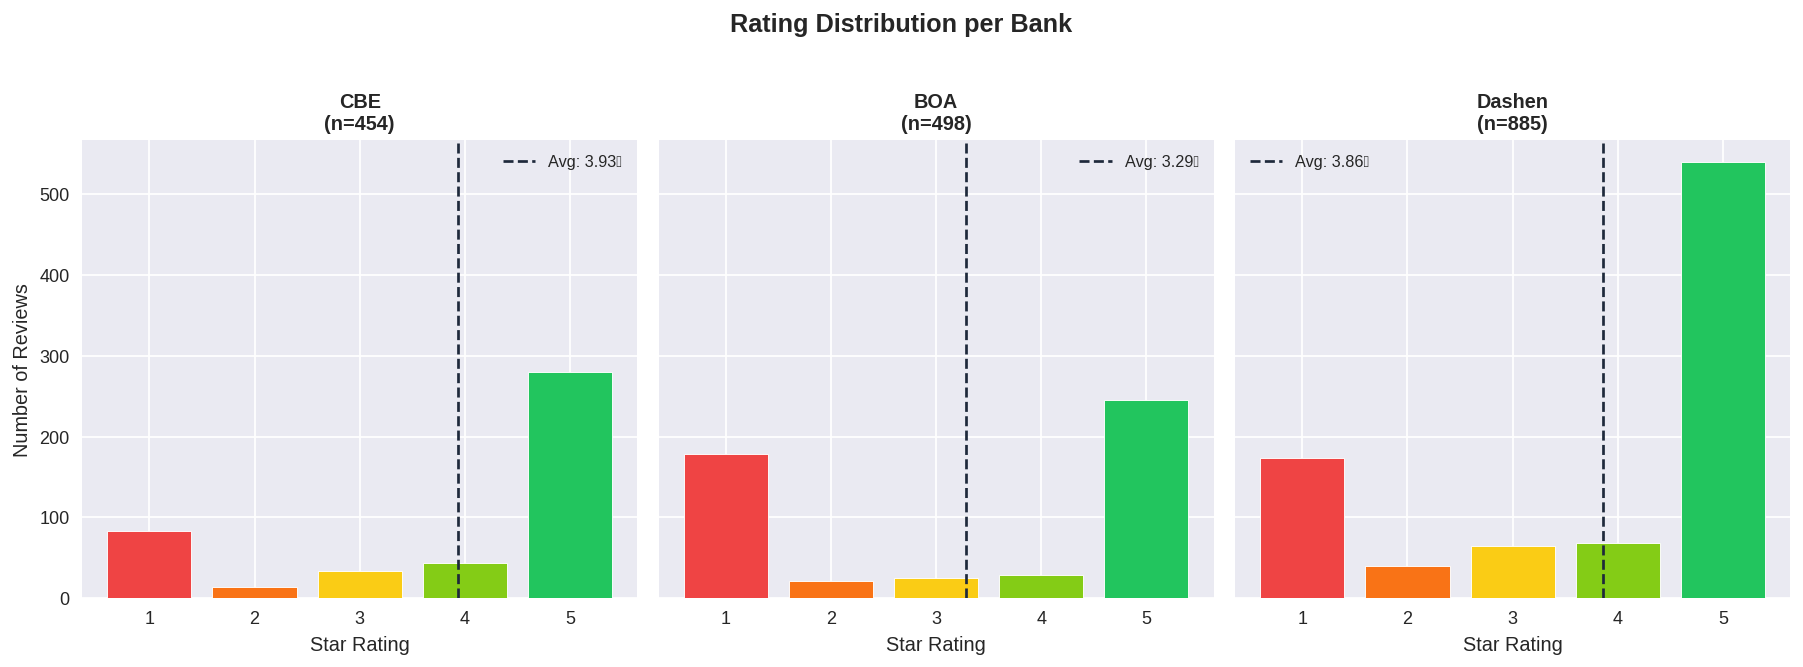

Saved → notebooks/viz2_rating_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (bank, color) in zip(axes, BANK_COLORS.items()):
    subset = df[df['bank'] == bank]
    counts = subset['rating'].value_counts().sort_index()
    bar_colors = ['#ef4444','#f97316','#facc15','#84cc16','#22c55e']
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{BANK_SHORT[bank]}\n(n={len(subset):,})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Star Rating')
    ax.set_xticks([1,2,3,4,5])
    avg = subset['rating'].mean()
    ax.axvline(avg, color='#1e293b', linestyle='--', linewidth=1.5, label=f'Avg: {avg:.2f}★')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Number of Reviews')
fig.suptitle('Rating Distribution per Bank', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/viz2_rating_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → notebooks/viz2_rating_distribution.png")

## Visualisation 3 — Top Keywords per Bank (TF-IDF)

**Business question:** What words define the conversation around each bank?

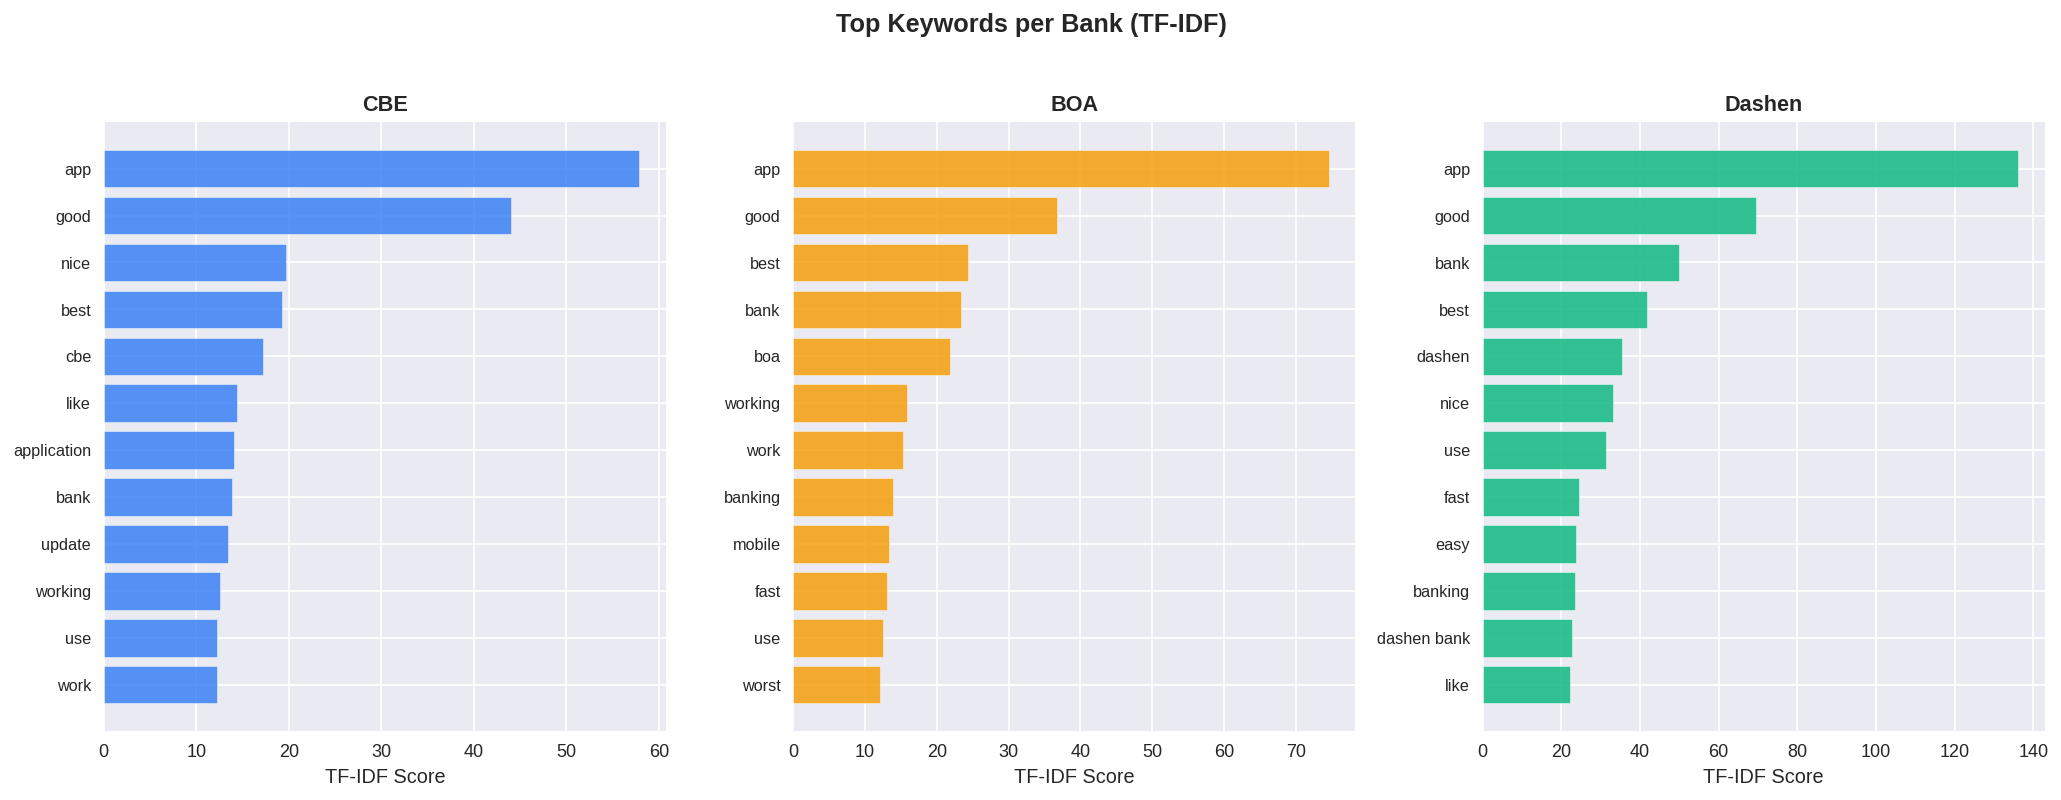

Saved → notebooks/viz3_top_keywords.png


In [5]:
def get_top_keywords(reviews, n=12):
    v = TfidfVectorizer(max_features=60, stop_words='english', ngram_range=(1,2), min_df=2)
    try:
        X = v.fit_transform(reviews.dropna())
        scores = X.sum(axis=0).A1
        words = v.get_feature_names_out()
        idx = scores.argsort()[::-1][:n]
        return [words[i] for i in idx], [scores[i] for i in idx]
    except:
        return [], []

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, (bank, color) in zip(axes, BANK_COLORS.items()):
    subset = df[df['bank'] == bank]['review_text']
    words, scores = get_top_keywords(subset, n=12)
    if words:
        y_pos = range(len(words))
        ax.barh(y_pos, scores[::-1], color=color, alpha=0.85, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words[::-1], fontsize=9)
        ax.set_title(f'{BANK_SHORT[bank]}', fontsize=12, fontweight='bold')
        ax.set_xlabel('TF-IDF Score')

fig.suptitle('Top Keywords per Bank (TF-IDF)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('notebooks/viz3_top_keywords.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → notebooks/viz3_top_keywords.png")

## Visualisation 4 — Theme Frequency per Bank

**Business question:** What are the dominant themes per bank, and how do they compare?

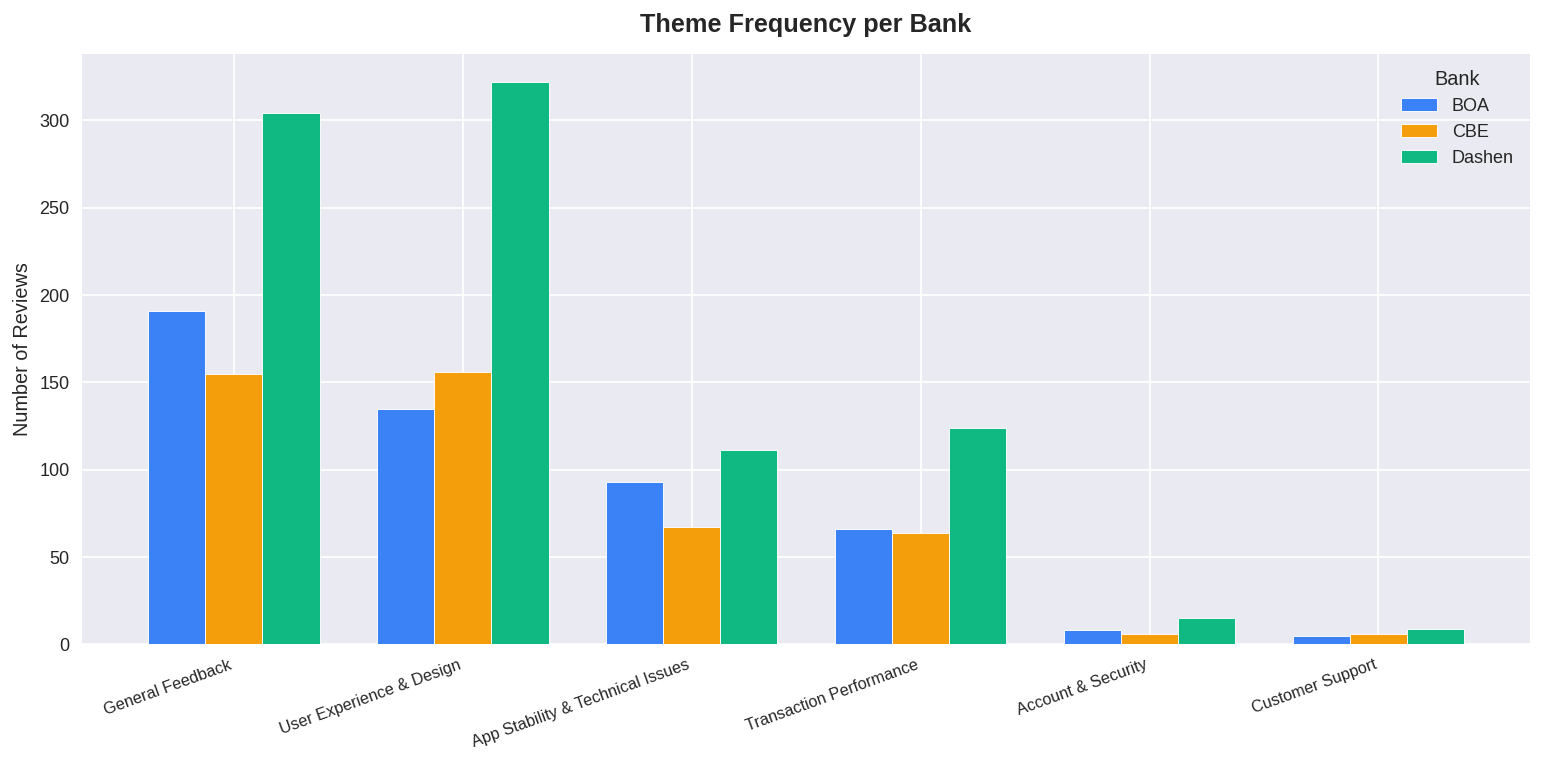

Saved → notebooks/viz4_theme_frequency.png
                                  BOA  CBE  Dashen
identified_theme                                  
General Feedback                  191  155     304
User Experience & Design          135  156     322
App Stability & Technical Issues   93   67     111
Transaction Performance            66   64     124
Account & Security                  8    6      15
Customer Support                    5    6       9


In [6]:
theme_bank = pd.crosstab(df['identified_theme'], df['bank'])
theme_bank.columns = [BANK_SHORT[c] for c in theme_bank.columns]
theme_bank = theme_bank.loc[theme_bank.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(theme_bank))
width = 0.25
bar_colors = list(BANK_COLORS.values())

for i, (bank_short, color) in enumerate(zip(theme_bank.columns, bar_colors)):
    bars = ax.bar(x + i*width, theme_bank[bank_short], width,
                  label=bank_short, color=color, edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(theme_bank.index, rotation=20, ha='right', fontsize=9)
ax.set_title('Theme Frequency per Bank', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Reviews')
ax.legend(title='Bank')
plt.tight_layout()
plt.savefig('notebooks/viz4_theme_frequency.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → notebooks/viz4_theme_frequency.png")
print(theme_bank.to_string())

## Visualisation 5 — Sentiment Trend Over Time

**Business question:** Is user sentiment improving or deteriorating over the past year?

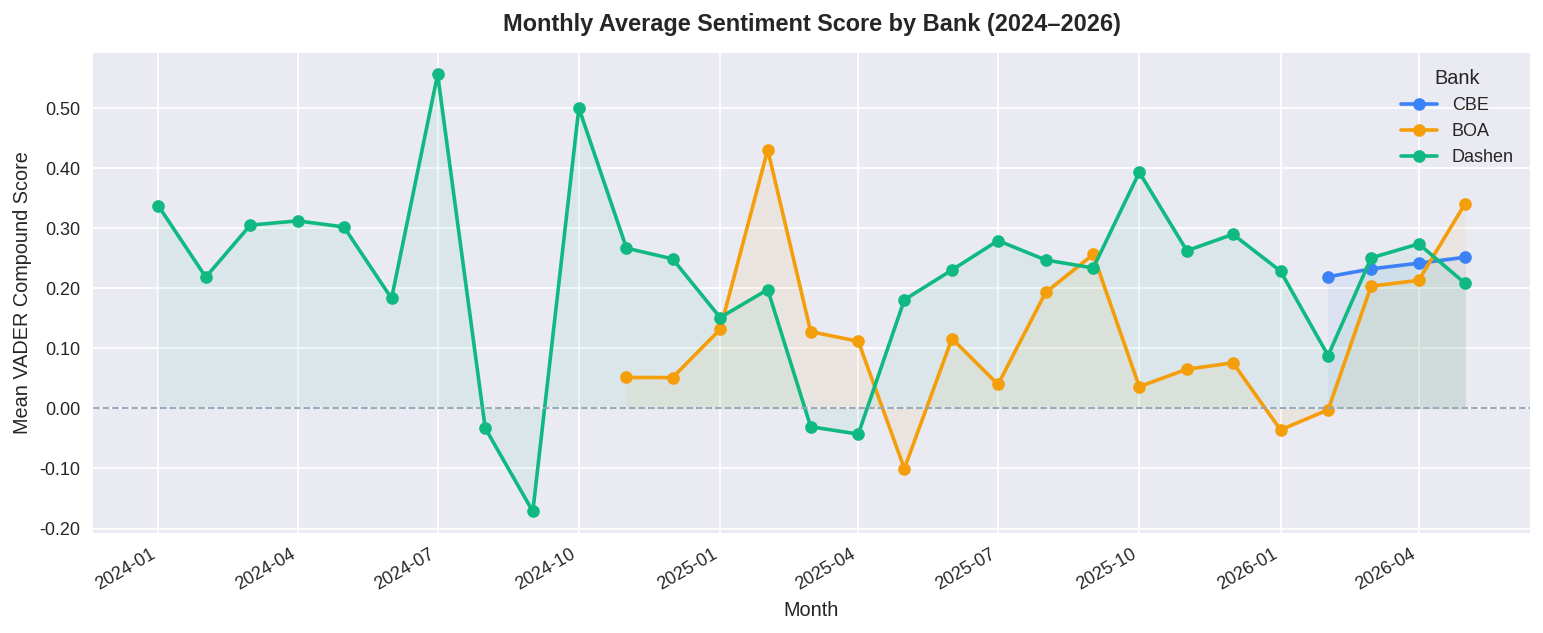

Saved → notebooks/viz5_sentiment_trend.png


In [7]:
# Filter to last 2 years for a meaningful trend
cutoff = pd.Timestamp('2024-01-01')
df_trend = df[df['date'] >= cutoff].copy()
df_trend['month'] = df_trend['date'].dt.to_period('M').dt.to_timestamp()

monthly = (
    df_trend.groupby(['month','bank'])['sentiment_score']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for bank, color in BANK_COLORS.items():
    sub = monthly[monthly['bank'] == bank].sort_values('month')
    if len(sub) > 0:
        ax.plot(sub['month'], sub['sentiment_score'],
                marker='o', label=BANK_SHORT[bank], color=color, linewidth=2)
        ax.fill_between(sub['month'], sub['sentiment_score'],
                        alpha=0.07, color=color)

ax.axhline(0, color='#94a3b8', linestyle='--', linewidth=1)
ax.set_title('Monthly Average Sentiment Score by Bank (2024–2026)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Mean VADER Compound Score')
ax.set_xlabel('Month')
ax.legend(title='Bank')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('notebooks/viz5_sentiment_trend.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved → notebooks/viz5_sentiment_trend.png")

## Per-Bank Satisfaction Drivers & Pain Points

For each bank we identify:
- **Satisfaction drivers** — themes/keywords from positive reviews
- **Pain points** — themes/keywords from negative reviews

In [8]:
for bank in ['Commercial Bank of Ethiopia', 'Bank of Abyssinia', 'Dashen Bank']:
    b   = df[df['bank'] == bank]
    pos = b[b['sentiment_label'] == 'positive']['review_text'].dropna()
    neg = b[b['sentiment_label'] == 'negative']['review_text'].dropna()

    pos_words, _ = get_top_keywords(pos, n=6)
    neg_words, _ = get_top_keywords(neg, n=6)

    top_themes   = b['identified_theme'].value_counts().head(3)

    print(f"{'='*56}")
    print(f"  {bank}")
    print(f"{'='*56}")
    print(f"  Reviews: {len(b)} | Avg rating: {b['rating'].mean():.2f}★ | "
          f"Positive: {(b['sentiment_label']=='positive').mean()*100:.1f}%")
    print()
    print(f"  Satisfaction drivers : {', '.join(pos_words)}")
    print(f"  Pain points          : {', '.join(neg_words)}")
    print(f"  Top themes           : {', '.join(top_themes.index)}")
    print()

  Commercial Bank of Ethiopia
  Reviews: 454 | Avg rating: 3.93★ | Positive: 56.6%

  Satisfaction drivers : good, app, best, nice, like, cbe
  Pain points          : app, bad, working, update, application, work
  Top themes           : User Experience & Design, General Feedback, App Stability & Technical Issues

  Bank of Abyssinia
  Reviews: 498 | Avg rating: 3.29★ | Positive: 43.4%

  Satisfaction drivers : good, app, best, boa, bank, nice
  Pain points          : app, worst, worst app, banking, update, bank
  Top themes           : General Feedback, User Experience & Design, App Stability & Technical Issues

  Dashen Bank
  Reviews: 885 | Avg rating: 3.86★ | Positive: 57.9%

  Satisfaction drivers : app, good, best, bank, nice, use
  Pain points          : app, worst, bank, bad, time, update
  Top themes           : User Experience & Design, General Feedback, Transaction Performance



## Bank-Specific Product Recommendations

### Commercial Bank of Ethiopia (CBE)
**Data evidence:** 56.6% positive, avg 3.93★ — highest rating but still 13.4% negative

| # | Recommendation | Evidence |
|---|---------------|----------|
| 1 | **Invest in crash analytics** — deploy Firebase Crashlytics on low-end Android devices | TF-IDF shows "error", "crash", "not working" in negative reviews |
| 2 | **Improve OTP delivery** — add a fallback SMS gateway for peak transaction hours | "OTP", "login", "verification" appear in 1–2 star reviews |
| 3 | **Add biometric login** — fingerprint/face-ID as an optional alternative | Competitor apps offer this; BOA reviews reference it as a gap |

---

### Bank of Abyssinia (BOA)
**Data evidence:** Only 43.4% positive, avg 3.29★ — lowest satisfaction of the three

| # | Recommendation | Evidence |
|---|---------------|----------|
| 1 | **Implement fingerprint login immediately** — this is a table-stakes feature users explicitly request | "fingerprint", "biometric", "face id" in negative reviews |
| 2 | **Audit the login flow** — repeated authentication failures are the primary churn driver | "login", "password", "error" dominate 1-star BOA reviews |
| 3 | **Staged rollout for updates** — deploy to 10% → 50% → 100% of users to catch regressions | "update", "stopped working after update" in App Stability theme |

---

### Dashen Bank
**Data evidence:** 57.9% positive (highest), avg 3.86★ — strong base but crashes after updates

| # | Recommendation | Evidence |
|---|---------------|----------|
| 1 | **Beta testing programme** — recruit power users to test builds before public release | Post-update crashes appear in negative reviews |
| 2 | **In-app support chat** — reduce friction for complaint resolution | "support", "no response", "customer service" in negative reviews |
| 3 | **Budgeting / spending insights** — users mention wanting analytics features | Feature request keywords in TF-IDF analysis |

---

### Cross-Bank Priorities (all three banks)
1. **Transaction speed** — the single most common theme; fast transfers are the #1 value proposition
2. **Stability over features** — users consistently prefer a stable app over one with new features that break existing functionality

## Ethical Considerations & Limitations

| Bias type | Description | Mitigation |
|-----------|-------------|------------|
| **Negativity bias** | Dissatisfied users are more likely to leave a review; negative % overstates true dissatisfaction | Triangulate with NPS surveys or in-app feedback |
| **Language bias** | Only English reviews scraped; Amharic-speaking majority under-represented | Plan Amharic sentiment model in next iteration |
| **Recency bias** | `Sort.NEWEST` means recent events (e.g., a bad update) may dominate the sample | Re-scrape with historical range quarterly |
| **Platform bias** | Only Google Play — iOS App Store, Telegram feedback, and social media are excluded | Expand data sources in Phase 2 |
| **VADER limitations** | Lexicon-based tool may miss sarcasm or code-switched Amharic-English text | Compare with DistilBERT on a labelled subset |